In [1]:
import os
import rioxarray as rxr
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import iris
import iris.plot as iplt
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import re
from tqdm import tqdm
from rioxarray.merge import merge_arrays

SOIL_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
CATCHMENT_DIR = "/scratch/hydro4/users/kv25483/FutureFlood/Data/CatchmentShapefiles/"

from functions import aggregate_to_5km, convert_to_netcdf

### Get hydraulic conductivity lookup

In [2]:
soils_lookup = pd.read_csv("../../Data/Soil_Info.csv")

# 1. Build a lookup dictionary from the CSV
#    adjust column name to match your actual hydraulic conductivity column
hc_lookup = dict(zip(
    soils_lookup["USDA_soil"],
    soils_lookup["Hydraulic_conductivity"]))

ep_lookup = dict(zip(
    soils_lookup["USDA_soil"],
    soils_lookup["Effective_porosity"]))

### Get catchment data

In [3]:
catchments = gpd.read_file(CATCHMENT_DIR + "hyd_areas_GB_with_subcatchments.shp")
ha_nums = catchments['HA_NUM']

### Join soil texture, hydraulic conductiity and effective porosity data over GB

In [4]:
hk_rasters_30m = []
ep_rasters_30m = []
texture_rasters_30m = [] 
lu_rasters_30m = [] 
fumax_rasters_30m = []



for ha_num in tqdm(ha_nums): 
    soil_file = SOIL_DIR + f"soil_30m_{ha_num}.tif" 
    if not os.path.exists(soil_file): 
        continue 
   
    # Get soil texture data 
    soil_texture = rxr.open_rasterio(soil_file).squeeze() 
    # avoid dask chunks here; merge wants computed arrays 
    soil_texture = soil_texture.where(soil_texture != -9999) 
    soil_values = soil_texture.values 
    
    #####################
    # Convert to HC values at 30cm
    #####################
    hk_values = np.full(soil_values.shape, np.nan, dtype=np.float32) 
    
    for usda_class, hk in hc_lookup.items(): 
        hk_values[soil_values == usda_class] = hk 
        
    hk_raster = soil_texture.copy(data=hk_values) 
    hk_raster.name = "hydraulic_conductivity" 
    hk_raster.rio.write_crs(soil_texture.rio.crs, inplace=True) 
    hk_raster.attrs["units"] = "cm hr-1"
    hk_raster.attrs["source"] = "Rawls et al. (1983) lookup by USDA soil texture class"
    
    #####################
    # Convert to EP values at 30cm
    #####################
    ep_values = np.full(soil_values.shape, np.nan, dtype=np.float32) 
    
    for usda_class, ep in ep_lookup.items(): 
        ep_values[soil_values == usda_class] = ep 
        
    ep_raster = soil_texture.copy(data=ep_values) 
    ep_raster.name = "effective_porosity" 
    ep_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)     
    ep_raster.attrs["units"] = "cm3 cm-3"
      
    #####################
    # Convert to effective depth (lu) values at 30cm
    #####################
    hk_values = hk_raster.values  # cm hr-1

    # Lu = 4*sqrt(Ks) is defined for Ks in in/hr, Lu in inches.
    # Converting units through (1 in = 2.54 cm, 1 m = 100 cm) collapses to:
    #   Lu[m] = 0.06375 * sqrt(Ks[cm/hr])
    lu_values = 0.06375 * np.sqrt(hk_values)

    lu_raster = soil_texture.copy(data=lu_values)
    lu_raster.name = "effective_depth"
    lu_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)
    lu_raster.attrs["units"] = "m"
    
    #####################
    # Convert to effective depth (lu) values at 30cm
    # Mirrors LISFLOOD-FP Initialize_GrnAmpt_Soiltype() exactly, step for step.
    #####################
    hk_values = hk_raster.values  # Rawls et al. (1983) Ks, cm/hr

    # Step 1: cm/hr -> mm/hr
    # (matches Get_Soil_Type(), where Rawls cm/hr values are hardcoded already *10 as mm/hr)
    ks_mm_hr = hk_values * 10.0

    # Step 2: mm/hr -> m/s
    # (matches: Infilptr->Ks[index] = C(...) / (1000 * 3600);)
    ks_m_s = ks_mm_hr / (1000.0 * 3600.0)

    # Step 3: Lu = 4*sqrt(25.4*3.6)*sqrt(Ks[m/s])
    # [empirical constant] × [unit-conversion factor] × [√Ks, per pixel]
    # (matches: Infilptr->Lu[index] = 4 * sqrt(25.4 * 3.6) * sqrt(Infilptr->Ks[index]);)
    lu_values = 4.0 * math.sqrt(25.4 * 3.6) * np.sqrt(ks_m_s)

    lu_raster = soil_texture.copy(data=lu_values)
    lu_raster.name = "effective_depth"
    lu_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)
    lu_raster.attrs["units"] = "m"
    lu_raster.attrs["source"] = "LISFLOOD-FP Initialize_GrnAmpt_Soiltype(), Lu = 4*sqrt(25.4*3.6)*sqrt(Ks[m/s])"
    
    
    #####################
    # Convert to potential capacity (Fumax = IMDmax * Lu) at 30cm
    #####################
    fumax_values = ep_raster.values * lu_raster.values

    fumax_raster = soil_texture.copy(data=fumax_values)
    fumax_raster.name = "potential_capacity"
    fumax_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)
    fumax_raster.attrs["units"] = "m"
    fumax_raster.attrs["source"] = "IMDmax * Lu, texture only (LISFLOOD-FP Fumax)"

        
    #####################
    # Append to lists
    #####################
    hk_rasters_30m.append(hk_raster)  
    ep_rasters_30m.append(ep_raster) 
    texture_rasters_30m.append(soil_texture)     
    lu_rasters_30m.append(lu_raster)
    fumax_rasters_30m.append(fumax_raster)
    
national_fumax_30m = merge_arrays(fumax_rasters_30m, nodata=np.nan)
national_fumax_30m.name = "potential_capacity"        
national_hc_30m = merge_arrays(hk_rasters_30m, nodata=np.nan) 
national_hc_30m.name = "hydraulic_conductivity" 

national_ep_30m = merge_arrays(ep_rasters_30m, nodata=np.nan) 
national_ep_30m.name = "effective_porosity" 

national_texture_30m = merge_arrays(texture_rasters_30m, nodata=np.nan) 
national_texture_30m.name = "soil_texture" 

national_lu_30m = merge_arrays(lu_rasters_30m, nodata=np.nan) 
national_lu_30m.name = "effective depth" 


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 114/114 [00:58<00:00,  1.96it/s]


In [9]:
import math

hk_values = hk_raster.values 
lu_values = np.full(hk_values.shape, np.nan, dtype=np.float32) 
lu_values = 4 * math.sqrt(hk_values)

TypeError: only length-1 arrays can be converted to Python scalars

### Aggregate to 5km

In [12]:
# Continuous
hk_5km = aggregate_to_5km(national_hc_30m, agg_type="mean")

# Continuous
ep_5km = aggregate_to_5km(national_ep_30m,agg_type="mean")

# Categorical
texture_5km = aggregate_to_5km(national_texture_30m, agg_type="mode")

Processing raster: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 71/71 [00:20<00:00,  3.54it/s]


### Check plotting

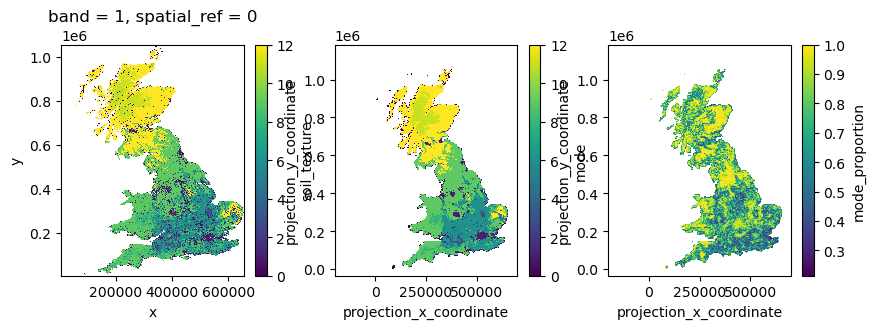

In [20]:
# hk_5km["aggregated_mean"].plot()
# ep_5km["aggregated_mean"].plot()

fig,axs=plt.subplots(ncols=3, figsize=(10,3))
plot_texture = national_hc_30m.isel( y=slice(None, None, 20),x=slice(None, None, 20))
plot_texture.plot(cmap="viridis", ax=axs[0], add_colorbar=True)
texture_5km["mode"].plot(ax=axs[1])
texture_5km["mode_proportion"].plot(ax=axs[2]);

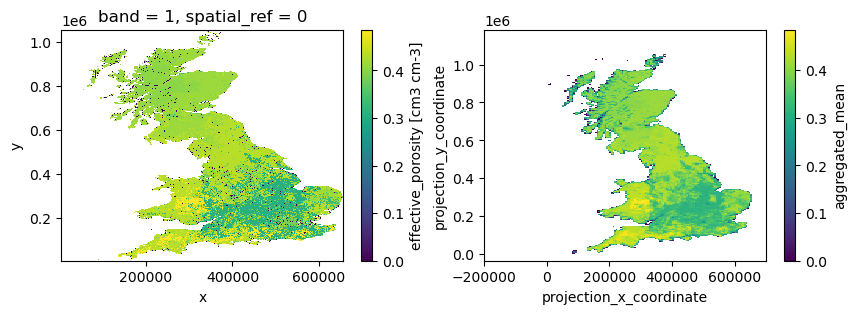

In [23]:
fig,axs=plt.subplots(ncols=2, figsize=(10,3))
plot_ep= national_ep_30m.isel( y=slice(None, None, 20),x=slice(None, None, 20))
plot_ep.plot(cmap="viridis", ax=axs[0], add_colorbar=True)
ep_5km["aggregated_mean"].plot(ax=axs[1]);

### Convert to a netCDF and save to file

In [21]:
hk_5km['aggregated_mean'].to_netcdf("../../Data/HydraulicConductivity/GB_5km_new.nc")
ep_5km['aggregated_mean'].to_netcdf("../../Data/EffectivePorosity/GB_5km_mean.nc")
texture_5km['mode'].to_netcdf("../../Data/SoilTexture/GB_5km_mode.nc")
texture_5km['mode_proportion'].to_netcdf("../../Data/SoilTexture/GB_5km_mode_prop.nc")